In [1]:
# need to restart jupyter server? kernal? whenever a change is made to the pybamm module? 
import sys
import os
sys.path.insert(0,os.path.dirname(os.path.dirname(os.path.dirname(os.path.abspath("__file__")))))
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))
# sys.path.insert(1,r'C:\Users\Vivian\Dropbox (University of Michigan)\from_box\Research\PyBaMM\PyBaMM\venv\Lib\MiKTeX')
import numpy as np
import pandas as pd
import math
import os
import matplotlib.pyplot as plt
# os.chdir(sys.path[0] + '\..') # change our working directory to the root of the pybamm folder
import pybamm
print(pybamm.__path__[0])
import dfols
from scipy import integrate, signal, constants

# import matplotlib
plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.serif': 'Computer Modern',
    'font.sans-serif': ['Computer Modern'],
    'font.size': 9,
})
%matplotlib widget
# pybamm.set_logging_level("INFO")

# reset plt settings
# import matplotlib as mpl
# mpl.rcParams.update(mpl.rcParamsDefault)

c:\Users\Vivian\Dropbox (University of Michigan)\from_box\Research\PyBaMM\PyBaMM\pybamm


# Set up simulation

In [2]:
class ExternalCircuitResistanceFunction():
    def __call__(self, variables):
        I = variables["Current [A]"]
        V = variables["Terminal voltage [V]"]
        R_ext = pybamm.FunctionParameter("External resistance [Ohm]",  {"Time [s]": pybamm.t}) 
        R_tab = pybamm.FunctionParameter("Tabbing resistance [Ohm]",  {"Time [s]": pybamm.t})
        return V/I - (R_ext + R_tab)

# Load data

In [3]:
Q_nom = 4.6
t_end = 15*60

def load_data(SOC_0, SOC_name):
    # load data import ESC data from file
    raw_data = pd.read_csv("ESC_"+  SOC_name + "SOC_full.csv")
    esc_start = raw_data[-raw_data['Current Shunt']>1].index[0]-1
    esc_end = raw_data[raw_data['Time (s)']>(raw_data['Time (s)'].loc[esc_start]+t_end)].index[0]
    T_amb = np.mean(raw_data['Cell Temperature'][(raw_data.index < esc_start) & (raw_data['Cell Temperature'] >0)])
    data = raw_data[['Time (s)', 'Voltage (V)', 'Cell Temperature', 'Current Shunt', 'Force']].loc[esc_start:esc_end].copy()
    data['Cell Temperature2'] = data['Cell Temperature'].copy() #make a copy 
    data['Cell Temperature'][data['Cell Temperature']>140] = None #filter original
    data.interpolate(inplace=True) #fill in nans for df
    data['Cell Temperature2'][data['Cell Temperature2']>140] = None #filter copy
    data['Current Shunt'] = -data['Current Shunt'] #- np.mean(raw_data['Current Shunt'].iloc[0:esc_start])) # remove offset
    data['Time (s)'] = data['Time (s)'] - data['Time (s)'].loc[esc_start]
    data['Force'] = (data['Force'] - data['Force'].loc[esc_start])*9.81
    df_labels = ['t', 'V', 'Temp','I', 'F', 'Temp2']
    data.set_axis(df_labels, axis=1, inplace=True)
    data['I_C'] = data.I/Q_nom 
    AhT_calculated = integrate.cumtrapz(abs(data.I), data.t-data.t.iloc[0])/3600
    AhT_calculated = np.append(AhT_calculated,AhT_calculated[-1])
    data['SOC'] = SOC_0 - AhT_calculated/Q_nom # load data import ESC data from file
    T_amb_0 = np.mean(raw_data['Cell Temperature'][(raw_data.index < esc_start) & (raw_data['Cell Temperature'] >0)])
    data.reset_index(drop=True, inplace=True)

    return data, T_amb_0

display(load_data(0.75, '75')[0])

C:\Users\Vivian\AppData\Local\Temp\ipykernel_33144\1601987789.py:19: FutureWarning: DataFrame.set_axis 'inplace' keyword is deprecated and will be removed in a future version. Use `obj = obj.set_axis(..., copy=False)` instead
  data.set_axis(df_labels, axis=1, inplace=True)
C:\Users\Vivian\AppData\Local\Temp\ipykernel_33144\1601987789.py:21: DeprecationWarning: 'scipy.integrate.cumtrapz' is deprecated in favour of 'scipy.integrate.cumulative_trapezoid' and will be removed in SciPy 1.14.0
  AhT_calculated = integrate.cumtrapz(abs(data.I), data.t-data.t.iloc[0])/3600


,t,V,Temp,I,F,Temp2,I_C,SOC
0,0.000,3.907343,21.886238,0.832958,0.000000,21.886238,0.181078,0.749301
1,0.100,1.447498,21.965434,230.630669,0.190512,21.965434,50.137102,0.747918
2,0.200,1.408588,21.896138,227.542398,0.730296,21.896138,49.465739,0.746547
3,0.300,1.388854,21.866438,226.594000,0.825552,21.866438,49.259565,0.745182
4,0.400,1.379884,21.995131,225.494177,0.984312,21.995131,49.020473,0.743822
...,...,...,...,...,...,...,...,...
8996,899.607,0.016445,67.207862,3.578503,-59.280996,67.207862,0.777935,0.132710
8997,899.707,0.016366,67.198277,3.526700,-59.471508,67.198277,0.766674,0.132689
8998,899.807,0.016405,67.198277,3.530685,-59.185740,67.198277,0.767540,0.132668
8999,899.907,0.016366,67.188692,3.538654,-59.503260,67.188692,0.769273,0.132646


In [4]:
def plot_dT_time(SOC_0, SOC_name):
    data = load_data(SOC_0, SOC_name)[0]
    dTdt_data = np.diff(data.Temp)/np.diff(data.t)
    dT_filtered = signal.savgol_filter(dTdt_data, 10*5,3)

    # plot 
    fig, ax= plt.subplots(1, 1, figsize=(8, 4), constrained_layout=True)
    # ax = ax.flatten()
    p1, = ax.plot(data.t[0:-1], dTdt_data, color = 'lightgrey', label = "Calculated dT/dt")
    p2, = ax.plot(data.t[0:-1], dT_filtered, color = 'k', label = "Filtered dT/dt")
    ax.set_ylabel("dT/dt [K.s-1]")
    ax.set_xlabel("Time [s]")
    ax.set_ylim([-0.5, 4])
    ax.set_xlim([0,t_end])

    ax2 = ax.twinx()
    p4, = ax2.plot(data.t, data.I, color = 'b', label = "Current")
    ax2.set_ylabel('Current [A]')
    ax2.yaxis.label.set_color(p4.get_color())
    ax2.tick_params(axis='y', colors=p4.get_color())
    ax2.spines.right.set_color(p4.get_color())

    ax3 = ax.twinx()
    ax3.spines.right.set_position(("axes", 1.2))
    p5, = ax3.plot(data.t, data.Temp2, color = 'g', label = "Temperature")
    ax3.set_ylabel("Temperature [$^\mathrm{o}$C]")
    ax3.yaxis.label.set_color(p5.get_color())
    ax3.tick_params(axis='y', colors=p5.get_color())
    ax3.spines.right.set_color(p5.get_color())

    ax1 = ax.twinx()
    ax1.spines.right.set_position(("axes", 1.4))
    p3, = ax1.plot(data.t, data.F, color = 'r', label = "Force")
    ax1.set_ylabel("$\Delta$ Force [N]")
    ax1.yaxis.label.set_color(p3.get_color())
    ax1.tick_params(axis='y', colors=p3.get_color())
    ax1.spines.right.set_color(p3.get_color())

    plt.title(str(int(SOC_0*100)) + "\% SOC$_0$ ESC")
    ax.legend(handles=[p1, p2, p3, p4, p5], loc = "upper right")
    # plt.tight_layout()
    plt.show()

# SOC_0 = 0.75
# SOC_name = '75'
# plot_dT_time(SOC_0, SOC_name)

C:\Users\Vivian\AppData\Local\Temp\ipykernel_33144\1601987789.py:19: FutureWarning: DataFrame.set_axis 'inplace' keyword is deprecated and will be removed in a future version. Use `obj = obj.set_axis(..., copy=False)` instead
  data.set_axis(df_labels, axis=1, inplace=True)
C:\Users\Vivian\AppData\Local\Temp\ipykernel_33144\1601987789.py:21: DeprecationWarning: 'scipy.integrate.cumtrapz' is deprecated in favour of 'scipy.integrate.cumulative_trapezoid' and will be removed in SciPy 1.14.0
  AhT_calculated = integrate.cumtrapz(abs(data.I), data.t-data.t.iloc[0])/3600
C:\Users\Vivian\AppData\Local\Temp\ipykernel_33144\3017975454.py:15: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim([-0.5, 4*60])


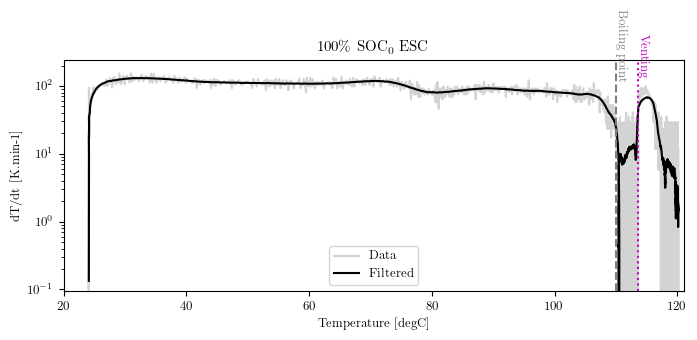

In [5]:
%matplotlib inline
def plot_dT_T(SOC_0, SOC_name):
    data = load_data(SOC_0, SOC_name)[0] 
    dTdt_data = np.diff(data.Temp)/(np.diff(data.t)/60)
    dT_filtered = signal.savgol_filter(dTdt_data, 10*5,3)

    # plot 
    t_plot_end = 120
    fig, ax= plt.subplots(1, 1, figsize=(8, 3))
    ax.semilogy(data.Temp[data.t<t_plot_end], dTdt_data[data.t[0:-1]<t_plot_end], color = "lightgrey", label = "Data")
    ax.semilogy(data.Temp[data.t<t_plot_end], dT_filtered[data.t[0:-1]<t_plot_end], color = "k", label = "Filtered")
    ax.set_xlabel("Temperature [degC]")
    ax.set_ylabel("dT/dt [K.min-1]")
    ax.legend()
    ax.set_ylim([-0.5, 4*60])
    ax.set_xlim([20,121])

    plt.title(str(int(SOC_0*100)) + "\% SOC$_0$ ESC")

    T_bps = [110]

    for T in T_bps:
        ylims = ax.get_ylim()
        ax.plot([T]*2, list(ylims), color = 'grey', linestyle = '--')
        ax.annotate('Boiling point', xy=(T, np.diff(ylims)*0.5+ ylims[0]), rotation=-90, color = 'grey')
        ax.set_ylim(ylims) # keep original limits

    if SOC_0 == 1: 
        chemistry = pybamm.parameter_sets.Tran2023
        param = pybamm.ParameterValues(chemistry)
        sigma_0 = param["Initial cell compression stress [kPa]"]
        data_sigma = data.F/param["Active material surface area [m2]"]/1000 - sigma_0
        sigma_max = max(42.35277961, max(data_sigma)) # from either 100% (default) or 100%F cell
        t_vent = data.t.iloc[0:-1][abs(np.diff(data['F'])) > 100].iloc[0]
        T_vent = data.Temp[abs(data.t-t_vent)<0.2].iloc[0]
        ax.plot([T_vent]*2, list(ylims), color = 'm', linestyle = ':')
        ax.annotate('Venting', xy=(T_vent, np.diff(ylims)*0.6+ ylims[0]), rotation=-90, color = 'm')
    # plt.tight_layout()
    plt.show()

SOC_0 = 1
SOC_name = '100A'
plot_dT_T(SOC_0, SOC_name)

C:\Users\Vivian\AppData\Local\Temp\ipykernel_33144\1601987789.py:19: FutureWarning: DataFrame.set_axis 'inplace' keyword is deprecated and will be removed in a future version. Use `obj = obj.set_axis(..., copy=False)` instead
  data.set_axis(df_labels, axis=1, inplace=True)
C:\Users\Vivian\AppData\Local\Temp\ipykernel_33144\1601987789.py:21: DeprecationWarning: 'scipy.integrate.cumtrapz' is deprecated in favour of 'scipy.integrate.cumulative_trapezoid' and will be removed in SciPy 1.14.0
  AhT_calculated = integrate.cumtrapz(abs(data.I), data.t-data.t.iloc[0])/3600


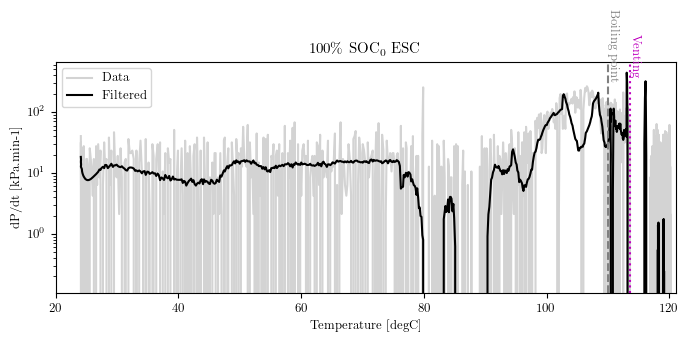

In [6]:
%matplotlib inline
def plot_dP_T(SOC_0, SOC_name):
    data = load_data(SOC_0, SOC_name)[0] 
    A_surf = 0.009
    dPdt_data = np.diff(data.F)/(np.diff(data.t)/60)/A_surf/1000
    dP_filtered = signal.savgol_filter(dPdt_data, 10*5,3)

    # plot 
    t_plot_end = 120
    fig, ax= plt.subplots(1, 1, figsize=(8, 3))
    ax.semilogy(data.Temp[data.t<t_plot_end], dPdt_data[data.t[0:-1]<t_plot_end], color = "lightgrey", label = "Data")
    ax.semilogy(data.Temp[data.t<t_plot_end], dP_filtered[data.t[0:-1]<t_plot_end], color = "k", label = "Filtered")
    ax.set_xlabel("Temperature [degC]")
    ax.set_ylabel("dP/dt [kPa.min-1]")
    ax.legend()
    # ax.set_ylim([-0.5, 6*60])
    ax.set_xlim([20,121])

    plt.title(str(int(SOC_0*100)) + "\% SOC$_0$ ESC")

    T_bps = [110]

    for T in T_bps:
        ylims = ax.get_ylim()
        ax.plot([T]*2, list(ylims), color = 'grey', linestyle = '--')
        ax.annotate('Boiling point', xy=(T, np.diff(ylims)*0.5+ ylims[0]), rotation=-90, color = 'grey')
        ax.set_ylim(ylims) # keep original limits

    if SOC_0 == 1: 
        chemistry = pybamm.parameter_sets.Tran2023
        param = pybamm.ParameterValues(chemistry)
        sigma_0 = param["Initial cell compression stress [kPa]"]
        data_sigma = data.F/param["Active material surface area [m2]"]/1000 - sigma_0
        sigma_max = max(42.35277961, max(data_sigma)) # from either 100% (default) or 100%F cell
        t_vent = data.t.iloc[0:-1][abs(np.diff(data['F'])) > 100].iloc[0]
        T_vent = data.Temp[abs(data.t-t_vent)<0.2].iloc[0]
        ax.plot([T_vent]*2, list(ylims), color = 'm', linestyle = ':')
        ax.annotate('Venting', xy=(T_vent, np.diff(ylims)*0.6+ ylims[0]), rotation=-90, color = 'm')
    # plt.tight_layout()
    plt.show()

SOC_0 = 1
SOC_name = '100A'
plot_dP_T(SOC_0, SOC_name)

In [7]:
def OCV_dim(self, soc):
    inputs = {
        "SOC": soc,
    }
    return pybamm.FunctionParameter("Cell open circuit voltage [V]", inputs)

# def ocv(soc):
#     p0 = np.array([0.114319142120841,  -0.663997904709863, 
#             1.686768366470837,  -2.462409468590447,   2.282769243949050, 
#             -1.401600551327618,   0.576551904459066,  -0.157044814050174, 
#             0.027351974716897,  -0.002866912229499,   0.000171009483610,
#             0.000029999998915])*1e5
#     return np.polyval(p0,soc)

def ocv(soc): # from C/10
    p0 = np.array([0.018506268107831,  -0.136071028323453, 
            0.443060938604833,  -0.839776753517996,   1.024213621638298, 
            -0.839264034243947,   0.470188190051651,  -0.183011124631359, 
            0.053509361841394,  -0.015162911494282,   0.005025031383283,
            -0.001474328544519, 0.000287406587189, -0.000032455129489, 
            0.000001937547848,  0.000000299017470
        ])*1e7
    return np.polyval(p0,soc)

C:\Users\Vivian\AppData\Local\Temp\ipykernel_33144\1601987789.py:19: FutureWarning: DataFrame.set_axis 'inplace' keyword is deprecated and will be removed in a future version. Use `obj = obj.set_axis(..., copy=False)` instead
  data.set_axis(df_labels, axis=1, inplace=True)
C:\Users\Vivian\AppData\Local\Temp\ipykernel_33144\1601987789.py:21: DeprecationWarning: 'scipy.integrate.cumtrapz' is deprecated in favour of 'scipy.integrate.cumulative_trapezoid' and will be removed in SciPy 1.14.0
  AhT_calculated = integrate.cumtrapz(abs(data.I), data.t-data.t.iloc[0])/3600
C:\Users\Vivian\AppData\Local\Temp\ipykernel_33144\3065690317.py:24: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim([-0.5, 4*60])


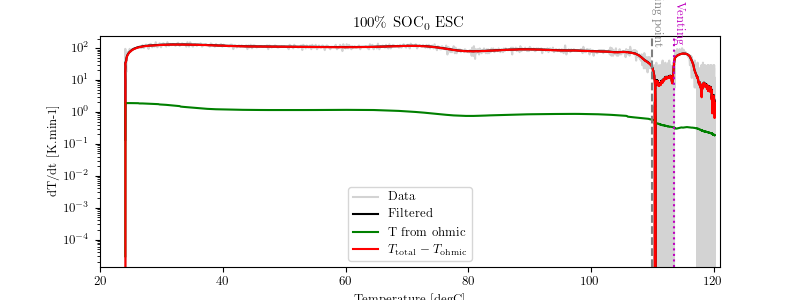

In [8]:
%matplotlib widget
SOC_0 = 1
SOC_name = '100A'

data = load_data(SOC_0, SOC_name)[0] 
dTdt_data = np.diff(data.Temp)/(np.diff(data.t)/60)
dT_filtered = signal.savgol_filter(dTdt_data, 10*5,3)

mCp = 0.12*2733 #guestimated m
dTohmdt_data = data.I*(ocv(data.SOC) - data.V)/mCp
dTohm_filtered = signal.savgol_filter(dTohmdt_data, 10*5,3)

# plot 
t_plot_end = 120
fig, ax= plt.subplots(1, 1, figsize=(8, 3))
ax.semilogy(data.Temp[data.t<t_plot_end], dTdt_data[data.t[0:-1]<t_plot_end], color = "lightgrey", label = "Data")
ax.semilogy(data.Temp[data.t<t_plot_end], dT_filtered[data.t[0:-1]<t_plot_end], color = "k", label = "Filtered")
ax.semilogy(data.Temp[data.t<t_plot_end], dTohmdt_data[data.t<t_plot_end], color = "g", label = "T from ohmic")
ax.semilogy(data.Temp[data.t<t_plot_end], dT_filtered[data.t[0:-1]<t_plot_end]-dTohm_filtered[data.t<t_plot_end], color = "r", label = "$T_{\mathrm{total}}-T_{\mathrm{ohmic}}$")

ax.set_xlabel("Temperature [degC]")
ax.set_ylabel("dT/dt [K.min-1]")
ax.legend()
ax.set_ylim([-0.5, 4*60])
ax.set_xlim([20,121])

plt.title(str(int(SOC_0*100)) + "\% SOC$_0$ ESC")

T_bps = [110]

for T in T_bps:
    ylims = ax.get_ylim()
    ax.plot([T]*2, list(ylims), color = 'grey', linestyle = '--')
    ax.annotate('Boiling point', xy=(T, np.diff(ylims)*0.5+ ylims[0]), rotation=-90, color = 'grey')
    ax.set_ylim(ylims) # keep original limits

if SOC_0 == 1: 
    chemistry = pybamm.parameter_sets.Tran2023
    param = pybamm.ParameterValues(chemistry)
    sigma_0 = param["Initial cell compression stress [kPa]"]
    data_sigma = data.F/param["Active material surface area [m2]"]/1000 - sigma_0
    sigma_max = max(42.35277961, max(data_sigma)) # from either 100% (default) or 100%F cell
    t_vent = data.t.iloc[0:-1][abs(np.diff(data['F'])) > 100].iloc[0]
    T_vent = data.Temp[abs(data.t-t_vent)<0.2].iloc[0]
    ax.plot([T_vent]*2, list(ylims), color = 'm', linestyle = ':')
    ax.annotate('Venting', xy=(T_vent, np.diff(ylims)*0.6+ ylims[0]), rotation=-90, color = 'm')
# plt.tight_layout()
plt.show()



# Nondimensional

## Check that model runs

In [9]:
def sim_thermal_fitting(h,Cp, SOC_0, T_amb_0, t, I, dV, I_offset = 0):  
    chemistry = pybamm.parameter_sets.Tran2023
    param = pybamm.ParameterValues(chemistry)

    param.update({
        "Ambient temperature [K]":T_amb_0 + 273.15,
        "Initial temperature [K]": T_amb_0 + 273.15,
        "Negative tab width [m]":2.5e-2,
        "Positive tab width [m]":2.5e-2,
        # "Edge heat transfer coefficient [W.m-2.K-1]":h,
        "Total heat transfer coefficient [W.m-2.K-1]":h,
        "Negative electrode specific heat capacity [J.kg-1.K-1]": 1100*Cp,
        "Positive electrode specific heat capacity [J.kg-1.K-1]": 1100*Cp,
        "Cell open circuit voltage [V]": ocv,
        "Cell capacity [A.h]": 4.6, #nominal
        "Typical current [A]": 4.6,
        "Negative electrode thickness [m]":62E-06*4.2/5,
        "Positive electrode thickness [m]":67E-06*4.2/5,
    }, check_already_exists = False)

    # Define input and output
    Q_vol_av = pybamm.Variable("Volume-averaged total heating")
    T_vol_av= pybamm.Variable("Volume-averaged cell temperature")

    # Init model and variables
    liion = pybamm.LithiumIonParameters()
    model = pybamm.BaseModel()
    Delta_T = param.evaluate(liion.Delta_T)
    T_ref = param.evaluate(liion.T_ref)
    tau_discharge = param.evaluate(liion.tau_discharge)
    tau_th_yz = param.evaluate(liion.tau_th_yz)
    model.timescale = pybamm.Scalar(tau_discharge)
    model.variables = {
        "Volume-averaged total heating": Q_vol_av, 
        "Volume-averaged cell temperature": T_vol_av,
        "Volume-averaged cell temperature [K]": Delta_T * T_vol_av + T_ref,
    }
    model.external_variables = [Q_vol_av]

    # Set up parameters
    # thermal = pybamm.thermal_parameters
    delta = param.evaluate(liion.delta) #self.L_x / self.L_z
    cell_surface_area = param.evaluate(liion.a_cooling) #self.A_cooling / (self.L_z ** 2)
    cell_volume = param.evaluate(liion.v_cell) # self.V_cell / (self.L_x * self.L_z ** 2)
    h_total = param.evaluate(liion.h_total) # self.h_total_dim * self.geo.L_x / self.lambda_eff_dim_ref
    rho = param.evaluate(liion.rho(T_vol_av)) # Dimensionless effective density? self.rho_dim(T_dim) * self.c_p_dim(T_dim) / self.main_param.rho_eff_dim_ref
    T_amb = param.evaluate(liion.T_amb(0)) # (self.T_amb_dim(t) - self.T_ref) / self.Delta_T
    total_cooling_coefficient = (
        -h_total
        * cell_surface_area
        / cell_volume
        / (delta ** 2))
    B = param.evaluate(liion.B) #self.B = (self.i_typ* self.R* self.T_ref* self.tau_th_yz/ (self.therm.rho_eff_dim_ref * self.F * self.Delta_T * self.L_x))
    C_th = param.evaluate(liion.tau_th_yz)/param.evaluate(liion.tau_discharge) # self.tau_th_yz / self.timescale
    Q_scale = param.evaluate(liion.i_typ) * param.evaluate(liion.potential_scale) / param.evaluate(liion.L_x)


    model.variables.update({
    "Volume-averaged total heating [W.m-3]": Q_vol_av * Q_scale,
    })

    # RHS
    model.rhs = {
        T_vol_av: (
            B * Q_vol_av + total_cooling_coefficient * (T_vol_av - T_amb)
        )/ (C_th * rho)
    }
    
    # set initial conditions
    T_init = param.evaluate(liion.T_init)
    model.initial_conditions = {T_vol_av: pybamm.Scalar(T_init)}

    # discretize
    disc = pybamm.Discretisation()  # use the default discretisation
    disc.process_model(model)

    # set Q as external variable
    Q_nom = param["Cell capacity [A.h]"]
    AhT_calculated = integrate.cumtrapz(abs(I), t-t[0])/3600
    AhT_calculated = np.append(AhT_calculated,AhT_calculated[-1])
    # soc = SOC_0 - AhT_calculated/Q_nom 
    Q_data = (I+I_offset)*dV #(ocv(soc)-V)

    # solve
    sim = pybamm.Simulation(model)
    V_cell_norm = param.evaluate(liion.L) *param.evaluate(liion.L_y) *param.evaluate(liion.L_z) 

    for (dt,q) in zip(np.diff(t), Q_data[0:-1]):
        external_variables = {"Volume-averaged total heating": q/V_cell_norm/Q_scale} 
        sim.step(dt, external_variables=external_variables)
    return sim

## Fitted thermal parameters

In [10]:
SOC_names = ['100A', '100B', '75', '50']
SOC_0s = {'100A': 1, '100B': 1, '75': 0.75, '50': 0.5}

# 100%SOC w=1 for all, rhoend =1e-3, 15 min ord = 1, k0 = [15,1]?
# Cps = {'100': 1.1797067, '100F': 1.10779815, '75': 0.97413164, '50': 0.97212067}
# hs = {'100': 16.58819844, '100F': 17.03975659, '75': 17.0676768  , '50': 23.44356758}

# w=0.1 for T>107, rhoend =1e-2, 15 min, MSE(e_T) + norm(e_dT, 1), k0 = [18,1]
# Cps = {'100': 1.19751277, '100F': 1.13849848, '75': 1.05227711, '50': 1.05403206}
# hs = {'100': 19.98369356, '100F': 19.77588117, '75': 19.97876587  , '50': 19.81620406}

# [17.81984063  1.09465293] #100F%SOC w=0.1 for T>107, rhoend =1e-2, 15 min, MSE(e_dT)/M(dT),k0 = [18,1]
# [19.99019775  1.20962392] #100%SOC w=0.1 for T>107, rhoend =1e-2, 15 min, MSE(e_dT)/M(dT),k0 = [18,1]
# [19.81810618  0.96645967] #75%SOC w=0.1 for T>107, rhoend =1e-2, 15 min, MSE(e_dT)/M(dT),k0 = [18,1]
# [20.00621175  1.0120845 ] #75%SOC w=0.1 for T>107, rhoend =1e-2, 15 min, MSE(e_dT)/M(dT),k0 = [18,1]
# Cps = {'100A': 1.20962392, '100B': 1.09465293, '75': 0.96645967, '50': 1.0120845}
# hs = {'100A': 19.99019775, '100B': 17.81984063, '75': 19.81810618, '50': 20.00621175}
Cps = {'100A': 2.4847642158614396, '100B': 2.131841251256563, '75': 1.7615851440073333, '50': 1.8069119898506183}    # 12/31 test   T only, no weights
hs = {'100A': 34.83874617168782, '100B': 34.211742173359575, '75': 37.17732764082647, '50': 35.31863975361435}   


## Plot data vs model

100A


C:\Users\Vivian\AppData\Local\Temp\ipykernel_33144\1601987789.py:19: FutureWarning: DataFrame.set_axis 'inplace' keyword is deprecated and will be removed in a future version. Use `obj = obj.set_axis(..., copy=False)` instead
  data.set_axis(df_labels, axis=1, inplace=True)
C:\Users\Vivian\AppData\Local\Temp\ipykernel_33144\1601987789.py:21: DeprecationWarning: 'scipy.integrate.cumtrapz' is deprecated in favour of 'scipy.integrate.cumulative_trapezoid' and will be removed in SciPy 1.14.0
  AhT_calculated = integrate.cumtrapz(abs(data.I), data.t-data.t.iloc[0])/3600
C:\Users\Vivian\AppData\Local\Temp\ipykernel_33144\3600675015.py:79: DeprecationWarning: 'scipy.integrate.cumtrapz' is deprecated in favour of 'scipy.integrate.cumulative_trapezoid' and will be removed in SciPy 1.14.0
  AhT_calculated = integrate.cumtrapz(abs(I), t-t[0])/3600
2024-05-23 17:06:20.449 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-05-23 17:06:20.

100B


2024-05-23 17:06:34.361 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-05-23 17:06:34.364 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-05-23 17:06:34.375 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')


75


2024-05-23 17:06:48.345 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-05-23 17:06:48.345 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-05-23 17:06:48.361 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')


50


2024-05-23 17:07:02.462 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-05-23 17:07:02.462 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-05-23 17:07:02.468 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


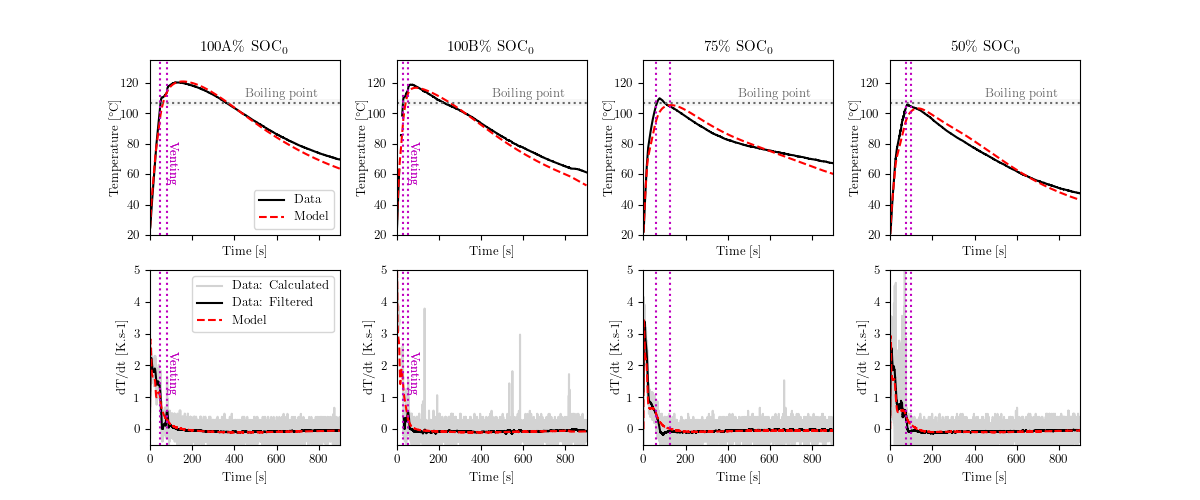

,SOC_names,rmse_T,rmse_bp,rmse_dT,e_T_max,T_hvap
0,100A,2.89,4.06,0.13,0.60,-7.49
1,100B,3.94,6.44,NaN,-2.06,-10.49
2,75,4.31,7.64,0.13,-4.47,-10.89
3,50,3.60,6.34,0.13,-2.36,-4.97


In [11]:
# save metrics
rmse_T = []
rmse_dT = [] #K.s-1
T_hvap = []
rmse_bp = []
e_T_max = []

# plot 
fig, ax= plt.subplots(2, len(SOC_names), figsize=(12, 5), gridspec_kw = {'wspace':0.3, 'hspace':0.2}, sharex=True) #, constrained_layout=True
for i,SOC_name in enumerate(SOC_names):
    print(SOC_name) 
    SOC_0 = SOC_0s[SOC_name]
    h = hs[SOC_name]
    Cp = Cps[SOC_name]
    data,T_amb_0 = load_data(SOC_0, SOC_name)
    solution = sim_thermal_fitting(h,Cp, SOC_0,T_amb_0,data.t,data.I,ocv(data.SOC)-data.V).solution
    t_sol, y_sol = solution.t, solution.y  # get solution times and states
    T_bp = 107
    T = solution["Volume-averaged cell temperature [K]"]
    rmse_T.append(np.sqrt(np.mean(np.square(data.Temp- (T(data.t)-273.15)))))

    dTdt_data = np.diff(data.Temp2)/np.diff(data.t)
    dT_filtered = signal.savgol_filter(dTdt_data, 10*16,3)
    T = solution['Volume-averaged cell temperature [K]']
    dTdt_sim = np.diff(T(data.t[0:-1]))/np.diff(data.t[0:-1])
    rmse_dT.append(np.sqrt(np.mean(np.square(dT_filtered[0:-1] - dTdt_sim))))

    # plot 
    ax[0,i].plot(data.t, data.Temp2, color = 'k', label = "Data")
    ax[0,i].plot(data.t, T(data.t)-273.15, color = 'r', linestyle = '--', label = "Model")
    ax[0,i].plot([0,t_end], [T_bp]*2, color = 'dimgrey', linestyle = ':')
    ax[0,i].axhspan(T_bp-2.2, T_bp+2.2, facecolor ='lightgrey', alpha = 0.2) 
    ax[0,i].annotate('Boiling point', xy=(t_end/2, T_bp+3), color = 'dimgrey')

    ax[0,i].set_xlabel("Time [s]")
    ax[0,i].set_ylabel("Temperature [$^\circ$C]", labelpad=0)
    ax[0,i].set_title(SOC_name + "\% SOC$_0$")
    ax[0,i].set_xlim([0,t_end])
    ax[0,i].set_ylim([20,135])
    if i ==0:
        ax[0,i].legend()

    ax[1,i].plot(data.t[0:-1], dTdt_data, color = 'lightgrey', label = "Data: Calculated")
    ax[1,i].plot(data.t[0:-1], dT_filtered, color = 'k', label = "Data: Filtered")
    ax[1,i].plot(data.t[0:-2], dTdt_sim, color = 'r', linestyle = '--', label = "Model")
    ax[1,i].set_ylabel("dT/dt [K.s-1]")
    ax[1,i].set_xlabel("Time [s]")
    ax[1,i].set_ylim([-0.5, 5])
    ax[1,i].set_xlim([0,t_end])
    if i ==0:
        ax[1,i].legend()

    t_boiling = data.t[(T_bp-2.2-data.Temp)<0.2].iloc[0]
    if SOC_0 ==1:
        t_vent = data.t.iloc[0:-1][abs(np.diff(data['F'])) > 100].iloc[0]
        t_vaps = [t_boiling, t_vent]
    else: 
        t_boiling2 = data.t[(T_bp-2.2-data.Temp)<0.2].iloc[-1]
        t_vaps = [t_boiling, t_boiling2]

    t_dT = (data.t[0:-1]>t_vaps[0]) & (data.t[0:-1]<t_vaps[1]) # time while vap
    T_hvap.append(np.trapz(dTdt_data[t_dT]-dTdt_sim[t_dT[0:-1]], data.t[0:-1][t_dT])) # dT loss from vap
    rmse_bp.append(np.sqrt(np.mean(np.square(data.Temp[data.t<t_vaps[0]]- (T(data.t[data.t<t_vaps[0]])-273.15))))) # before bp

    # for axs in fig.get_axes():
    for j, t_vap in enumerate(t_vaps):
        for k in range(0,2):
            ylims = ax[k,i].get_ylim()
            if j ==0:
                ax[k,i].plot([t_vap]*2, list(ylims), color = 'm', linestyle = ':', label = 'Electrolyte vaporization') #(T$>$' + str(T_bp) + '$^\circ$C)
            else:
                ax[k,i].plot([t_vap]*2, list(ylims), color = 'm', linestyle = ':')
            ax[k,i].set_ylim(ylims) # keep original limits
                # axs.legend()
            if (SOC_0 ==1):# and (l == len(solutions)-1):
                t_vent = data.t.iloc[0:-1][abs(np.diff(data['F'])) > 100].iloc[0]
                T_vent = data.Temp[abs(data.t-t_vent)<0.2].iloc[0]
                # ylims = axs.get_ylim()
                # axs.annotate('Boiling', xy=(t_boiling-35, np.diff(ylims)*0.5+ ylims[0]), rotation=-90, color = 'm')
                # axs.plot([t_vent]*2, list(ylims), color = 'm', linestyle = '--')
                ax[k,i].annotate('Venting', xy=(t_vent, np.diff(ylims)*0.3+ ylims[0]), rotation=-90, color = 'm')
                ax[k,i].set_ylim(ylims) # keep original limits
    
    T_max_sim = max(T(data.t)-273.15)
    T_max_data = max(data.Temp) 
    e_T_max.append(T_max_sim -  T_max_data)
                
# plt.tight_layout()
# plt.subplots_adjust(wspace=0, hspace=0)
# fig.suptitle(str(int(1*100)) + "\% SOC$_0$", y=1, x = 0.55)
plt.savefig('./figs/all_ESC_thermal_fit.eps', format='eps', dpi = 300)
plt.show()


df = pd.DataFrame(list(zip(SOC_names,rmse_T , rmse_bp, rmse_dT, e_T_max, T_hvap, )),
               columns =['SOC_names','rmse_T' , 'rmse_bp', 'rmse_dT', 'e_T_max', 'T_hvap', ])
display(round(df,2))

# PLOT: Thermal fit with inset

In [12]:
datas = []
solutions = []
for i,SOC_name in enumerate(SOC_names):
    print(SOC_name)

    SOC_0 = SOC_0s[SOC_name]
    h = hs[SOC_name]
    Cp = Cps[SOC_name]
    data,T_amb_0 = load_data(SOC_0, SOC_name)
    datas.append(data)
    solutions.append(sim_thermal_fitting(h,Cp, SOC_0,T_amb_0,data.t,data.I,ocv(data.SOC)-data.V).solution)
    

100A
100B
75
50


2024-05-23 17:08:32.631 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-05-23 17:08:32.631 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-05-23 17:08:32.698 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')


100A
100B


2024-05-23 17:08:32.998 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-05-23 17:08:32.998 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-05-23 17:08:33.064 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')


75


2024-05-23 17:08:33.376 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-05-23 17:08:33.381 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-05-23 17:08:33.415 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')


75
50


2024-05-23 17:08:33.730 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-05-23 17:08:33.730 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-05-23 17:08:33.780 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


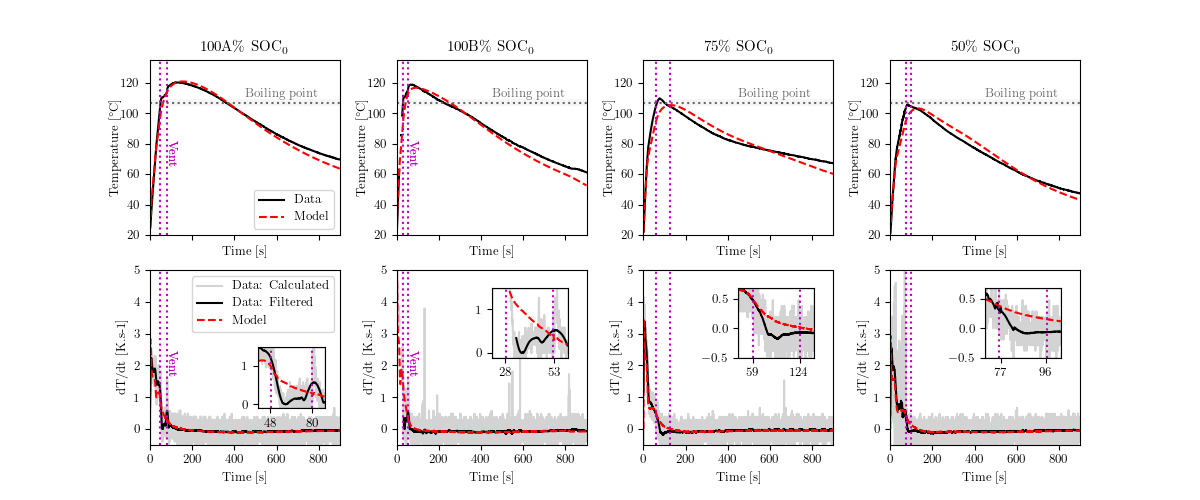

,SOC_names,rmse_T,rmse_bp,rmse_dT,e_T_max,T_hvap
0,100A,2.89,4.06,0.13,0.60,-7.49
1,100B,3.94,6.44,NaN,-2.06,-10.49
2,75,4.31,7.64,0.13,-4.47,-10.89
3,50,3.60,6.34,0.13,-2.36,-4.97


No such comm: ec4db271c0144f35afb854e3352b89be


In [13]:
# save metrics
rmse_T = []
rmse_dT = [] #K.s-1
T_hvap = []
rmse_bp = []
e_T_max = []

# plot 
fig, ax= plt.subplots(2, len(SOC_names), figsize=(12, 5), gridspec_kw = {'wspace':0.3, 'hspace':0.2}, sharex=True) #, constrained_layout=True
for i,(SOC_name,data,solution) in enumerate(zip(SOC_names, datas, solutions)):
    print(SOC_name) 
    SOC_0 = SOC_0s[SOC_name]
    # h = hs[SOC_name]
    # Cp = Cps[SOC_name]
    # data,T_amb_0 = load_data(SOC_0, SOC_name)
    # solution = sim_thermal_nondim(h,Cp).solution
    # t_sol, y_sol = solution.t, solution.y  # get solution times and states
    T_bp = 107
    T = solution["Volume-averaged cell temperature [K]"]
    rmse_T.append(np.sqrt(np.mean(np.square(data.Temp- (T(data.t)-273.15)))))

    dTdt_data = np.diff(data.Temp2)/np.diff(data.t)
    dT_filtered = signal.savgol_filter(dTdt_data, 10*16,3)
    T = solution['Volume-averaged cell temperature [K]']
    dTdt_sim = np.diff(T(data.t[0:-1]))/np.diff(data.t[0:-1])
    rmse_dT.append(np.sqrt(np.mean(np.square(dT_filtered[0:-1] - dTdt_sim))))

    # plot 
    ax[0,i].plot(data.t, data.Temp2, color = 'k', label = "Data")
    ax[0,i].plot(data.t, T(data.t)-273.15, color = 'r', linestyle = '--', label = "Model")
    ax[0,i].plot([0,t_end], [T_bp]*2, color = 'dimgrey', linestyle = ':')
    ax[0,i].axhspan(T_bp-2.2, T_bp+2.2, facecolor ='lightgrey', alpha = 0.2) 
    ax[0,i].annotate('Boiling point', xy=(t_end/2, T_bp+3), color = 'dimgrey')

    ax[0,i].set_xlabel("Time [s]")
    ax[0,i].set_ylabel("Temperature [$^\circ$C]", labelpad=0)
    ax[0,i].set_title(SOC_name + "\% SOC$_0$")
    ax[0,i].set_xlim([0,t_end])
    ax[0,i].set_ylim([20,135])
    if i ==0:
        ax[0,i].legend()

    ax[1,i].plot(data.t[0:-1], dTdt_data, color = 'lightgrey', label = "Data: Calculated")
    ax[1,i].plot(data.t[0:-1], dT_filtered, color = 'k', label = "Data: Filtered")
    ax[1,i].plot(data.t[0:-2], dTdt_sim, color = 'r', linestyle = '--', label = "Model")
    ax[1,i].set_ylabel("dT/dt [K.s-1]")
    ax[1,i].set_xlabel("Time [s]")
    ax[1,i].set_ylim([-0.5, 5])
    ax[1,i].set_xlim([0,t_end])
    if i ==0:
        ax[1,i].legend()

    t_boiling = data.t[(T_bp-2.2-data.Temp)<0.2].iloc[0]
    if SOC_0 ==1:
        t_vent = data.t.iloc[0:-1][abs(np.diff(data['F'])) > 100].iloc[0]
        t_vaps = [t_boiling, t_vent]
    else: 
        t_boiling2 = data.t[(T_bp-2.2-data.Temp)<0.2].iloc[-1]
        t_vaps = [t_boiling, t_boiling2]

    t_dT = (data.t[0:-1]>t_vaps[0]) & (data.t[0:-1]<t_vaps[1])
    T_hvap.append(np.trapz(dTdt_data[t_dT]-dTdt_sim[t_dT[0:-1]], data.t[0:-1][t_dT]))
    rmse_bp.append(np.sqrt(np.mean(np.square(data.Temp[data.t<t_vaps[0]]- (T(data.t[data.t<t_vaps[0]])-273.15)))))

    # for axs in fig.get_axes():
    for j, t_vap in enumerate(t_vaps):
        for k in range(0,2):
            ylims = ax[k,i].get_ylim()
            if j ==0:
                ax[k,i].plot([t_vap]*2, list(ylims), color = 'm', linestyle = ':', label = 'Electrolyte vaporization') #(T$>$' + str(T_bp) + '$^\circ$C)
            else:
                ax[k,i].plot([t_vap]*2, list(ylims), color = 'm', linestyle = ':')
            ax[k,i].set_ylim(ylims) # keep original limits
                # axs.legend()
            if (SOC_0 ==1):# and (l == len(solutions)-1):
                t_vent = data.t.iloc[0:-1][abs(np.diff(data['F'])) > 100].iloc[0]
                T_vent = data.Temp[abs(data.t-t_vent)<0.2].iloc[0]
                # ylims = axs.get_ylim()
                # axs.annotate('Boiling', xy=(t_boiling-35, np.diff(ylims)*0.5+ ylims[0]), rotation=-90, color = 'm')
                # axs.plot([t_vent]*2, list(ylims), color = 'm', linestyle = '--')
                ax[k,i].annotate('Vent', xy=(t_vent, np.diff(ylims)*0.4+ ylims[0]), rotation=-90, color = 'm')
                ax[k,i].set_ylim(ylims) # keep original limits
    
    
    if SOC_name in ['100A', '100B','75', '50']:
        # inset axes....
        buffer = (t_vaps[1]-t_vaps[0])*0.3
        extent = (0,t_end,-0.5, 5)
        i_ins = (data.t>t_vaps[0]-buffer) & (data.t<t_vaps[1]+buffer)
        if SOC_name == '100B':
            ax2 = ax[1,i].inset_axes([.5, .5, .4, .4],xlim = (t_vaps[0]-buffer, t_vaps[1]+buffer), ylim = (-0.1, 1.5), xticks=list(np.round(t_vaps)))  # subregion of original plot yticklabels=[]
        elif SOC_name == '100A':
            ax2 = ax[1,i].inset_axes([.57, .21, .35, .35],xlim = (t_vaps[0]-buffer, t_vaps[1]+buffer), ylim = (-0.1, 1.5), xticks=list(np.round(t_vaps)))  # subregion of original plot yticklabels=[]
        else:
            ax2 = ax[1,i].inset_axes([.5, .5, .4, .4],xlim = (t_vaps[0]-buffer, t_vaps[1]+buffer), ylim = (-0.5, 1-0.3), xticks=list(np.round(t_vaps)), yticks=[-0.5, 0, 0.5])  # subregion of original plot

        ax2.plot(data.t[i_ins], dTdt_data[i_ins[0:-1]], color = 'lightgrey', label = "Data: Calculated")
        ax2.plot(data.t[i_ins], dT_filtered[i_ins[0:-1]], color = 'k', label = "Data: Filtered")
        ax2.plot(data.t[i_ins], dTdt_sim[i_ins[0:-2]], color = 'r', linestyle = '--', label = "Model")  
        ylims = ax2.get_ylim()
        for t_vap in t_vaps:
            ax2.plot([t_vap]*2, list(ylims), color = 'm', linestyle = ':')
        # ax2 = ax[1,i].inset_axes([0.5, 0.5, 0.47, 0.47],xlim=(x1, x2), ylim=(y1, y2), xticklabels=[], yticklabels=[])
        # ax2.imshow(data[x1:x2, y1:y2], origin="lower")
        ax2.indicate_inset_zoom(ax2, edgecolor="black")

    T_max_sim = max(T(data.t)-273.15)
    T_max_data = max(data.Temp) 
    e_T_max.append(T_max_sim -  T_max_data)
                
# plt.tight_layout()
# plt.subplots_adjust(wspace=0, hspace=0)
# fig.suptitle(str(int(1*100)) + "\% SOC$_0$", y=1, x = 0.55)
plt.savefig('./figs/all_ESC_thermal_fit_inset.eps', format='eps', dpi = 300)
plt.show()


df = pd.DataFrame(list(zip(SOC_names,rmse_T , rmse_bp, rmse_dT, e_T_max, T_hvap, )),
               columns =['SOC_names','rmse_T' , 'rmse_bp', 'rmse_dT', 'e_T_max', 'T_hvap', ])
display(round(df,2))

# Plot thermal fit with inset and I error

In [14]:
datas = []
solutions = []
for i,SOC_name in enumerate(SOC_names):
    print(SOC_name) 
    SOC_0 = SOC_0s[SOC_name]
    h = hs[SOC_name]
    Cp = Cps[SOC_name]
    data,T_amb_0 = load_data(SOC_0, SOC_name)
    datas.append(data)
    cell_solutions=[]
    cell_solutions.append(sim_thermal_fitting(h,Cp, SOC_0,T_amb_0,data.t,data.I,ocv(data.SOC)-data.V).solution)
    # cell_solutions.append(sim_thermal_nondim(h,Cp, I_offset = 5).solution)
    # cell_solutions.append(sim_thermal_nondim(h,Cp, I_offset = -5).solution)
    cell_solutions.append(sim_thermal_fitting(h,Cp, SOC_0,T_amb_0,data.t,data.I,ocv(data.SOC)-data.V,I_offset = 0.5 + data.I*(0.01)).solution)
    cell_solutions.append(sim_thermal_fitting(h,Cp, SOC_0,T_amb_0,data.t,data.I,ocv(data.SOC)-data.V,I_offset = -0.5 - data.I*(0.01)).solution)
    # cell_solutions.append(sim_thermal_nondim(h,Cp, I_offset = data.I*(0.01)).solution)
    # cell_solutions.append(sim_thermal_nondim(h,Cp, I_offset = -data.I*(0.01)).solution)
    solutions.append(cell_solutions)
    

100A
100B
75
50


2024-05-23 17:47:19.397 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-05-23 17:47:19.401 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-05-23 17:47:19.403 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-05-23 17:47:19.404 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-05-23 17:47:19.433 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-05-23 17:47:19.433 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-05-23 17:47:19.433 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-05-23 17:47:19.433 - [WARNING] processed_variable.__call__(459): Calling varia

100A
100B
75
50


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


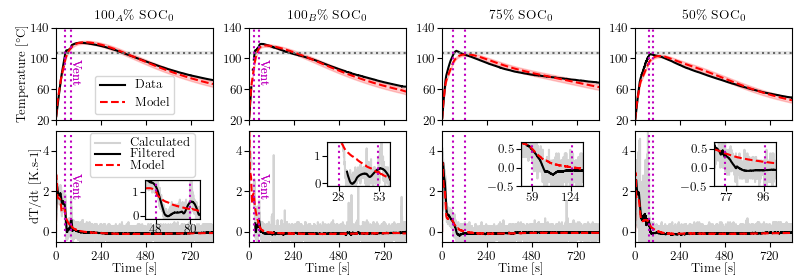

,SOC_names,rmse_T,rmse_bp,rmse_dT,e_T_max,T_hvap
0,100A,2.89,4.06,0.13,0.60,-7.49
1,100B,3.94,6.44,0.09,-2.06,-10.49
2,75,4.31,7.64,0.13,-4.47,-10.89
3,50,3.60,6.34,0.13,-2.36,-4.97


In [28]:
%matplotlib widget
# plt.clf()
# save metrics
rmse_T = []
rmse_dT = [] #K.s-1
T_hvap = []
rmse_bp = []
e_T_max = []

# plot 
# fig, ax= plt.subplots(2, len(SOC_names), figsize=(6.75, 3.25),sharex=True) # figsize=(6.75, 3.1) BREAKS SAVEFIG TO EPS. MISSING RIGHT AXES
# plt.subplots_adjust(left=0.07, bottom=0.12, right=0.99, top=0.9, wspace=0.23, hspace=0.1)
# ECS poster
fig, ax= plt.subplots(2, len(SOC_names), figsize=(8, 2.75),sharex=True, height_ratios= [1,1.2]) # figsize=(6.75, 3.1) BREAKS SAVEFIG TO EPS. MISSING RIGHT AXES
plt.subplots_adjust(left=0.07, bottom=0.12, right=0.99, top=0.9, wspace=0.23, hspace=0.1, )


for i,(SOC_name,data,cell_solutions) in enumerate(zip(SOC_names, datas, solutions)):
    solution = cell_solutions[0]
    print(SOC_name) 
    SOC_0 = SOC_0s[SOC_name]
    # h = hs[SOC_name]
    # Cp = Cps[SOC_name]
    # data,T_amb_0 = load_data(SOC_0, SOC_name)
    # solution = sim_thermal_nondim(h,Cp).solution
    # t_sol, y_sol = solution.t, solution.y  # get solution times and states
    T_bp = 107
    T = solution["Volume-averaged cell temperature [K]"]
    T_min = cell_solutions[1]["Volume-averaged cell temperature [K]"]
    T_max = cell_solutions[2]["Volume-averaged cell temperature [K]"]
    rmse_T.append(np.sqrt(np.mean(np.square(data.Temp- (T(data.t)-273.15)))))

    dTdt_data = np.diff(data.Temp2)/np.diff(data.t)
    dT_filtered = signal.savgol_filter(dTdt_data, 10*15,3)
    dTdt_sim = np.diff(T(data.t[0:-1]))/np.diff(data.t[0:-1])
    # dTdt_sim_min = np.diff(T_min(data.t[0:-1]))/np.diff(data.t[0:-1])
    # dTdt_sim_max = np.diff(T_max(data.t[0:-1]))/np.diff(data.t[0:-1])

    rmse_dT.append(np.sqrt(np.mean(np.square((dT_filtered[0:-1] - dTdt_sim)[~np.isnan(dT_filtered[0:-1])])))) # ignore nan

    # plot 
    ax[0,i].plot(data.t, data.Temp2, color = 'k', label = "Data")
    ax[0,i].plot(data.t, T(data.t)-273.15, color = 'r', linestyle = '--', label = "Model")
    ax[0,i].fill_between(data.t, T_min(data.t)-273.15, T_max(data.t)-273.15, color = 'r', alpha=0.2,zorder=-10)

    ax[0,i].plot([0,t_end], [T_bp]*2, color = 'dimgrey', linestyle = ':')
    ax[0,i].axhspan(T_bp-2.2, T_bp+2.2, facecolor ='lightgrey', alpha = 0.5,zorder=-10) 
    ax[0,i].annotate('Boiling point', xy=(t_end*0.99, T_bp+3), color = 'dimgrey', ha='right')
    ax[0,i].set_xticks(np.arange(0,t_end, step=60*4))

    # ax[0,i].set_xlabel("Time [s]", labelpad=0)
    if i ==0:
        ax[0,i].set_ylabel("Temperature [$^\circ$C]", labelpad=2)
    # ax[0,i].set_title('Cell ' + SOC_name, fontsize = 9.5)
    if SOC_name == '100A':
        ax[0,i].set_title( str(int(SOC_0*100)) + '$_A$\% SOC$_0$', fontsize = 9.5) #ECS poster

    elif SOC_name == '100B':
        ax[0,i].set_title( str(int(SOC_0*100)) + '$_B$\% SOC$_0$', fontsize = 9.5) #ECS poster

    else:
        ax[0,i].set_title( str(int(SOC_0*100)) + '\% SOC$_0$', fontsize = 9.5) #ECS poster
    ax[0,i].set_xlim([0,t_end])
    ax[0,i].set_ylim([20,135])
    ax[0,i].set_yticks(np.arange(20,141, step=40))

    if i ==0:
        ax[0,i].legend()

    ax[1,i].plot(data.t[0:-1], dTdt_data, color = 'lightgrey', label = "Calculated")
    ax[1,i].plot(data.t[0:-1], dT_filtered, color = 'k', label = "Filtered")
    ax[1,i].plot(data.t[0:-2], dTdt_sim, color = 'r', linestyle = '--', label = "Model")
    # ax[1,i].fill_between(data.t[0:-2], dTdt_sim_min,dTdt_sim_max, color = 'r') #offset doesn't change 
    if i ==0:
        ax[1,i].set_ylabel("dT/dt [K.s-1]",labelpad=2)
    ax[1,i].set_xlabel("Time [s]", labelpad=0)
    ax[1,i].set_ylim([-0.5, 5])
    ax[1,i].set_xlim([0,t_end])
    ax[1,i].set_xticks(np.arange(0,t_end, step=60*4))
    if i ==0:
        ax[1,i].legend(loc='upper center', labelspacing = 0, bbox_to_anchor=(0.55, 1.03))

    try:
        t_boiling = data.t[(T_bp-2.2-data.Temp)<0.2].iloc[0]

        if SOC_0 ==1:
            t_vent = data.t.iloc[0:-1][abs(np.diff(data['F'])) > 100].iloc[0]
            t_vaps = [t_boiling, t_vent]
        else: 
            t_boiling2 = data.t[(T_bp-2.2-data.Temp)<0.2].iloc[-1]
            t_vaps = [t_boiling, t_boiling2]

        t_dT = (data.t[0:-1]>t_vaps[0]) & (data.t[0:-1]<t_vaps[1])
        T_hvap.append(np.trapz(dTdt_data[t_dT]-dTdt_sim[t_dT[0:-1]], data.t[0:-1][t_dT]))
        rmse_bp.append(np.sqrt(np.mean(np.square(data.Temp[data.t<t_vaps[0]]- (T(data.t[data.t<t_vaps[0]])-273.15)))))

    except: 
        t_boiling = []
        T_hvap.append(None)
        rmse_bp.append(None)

    # for axs in fig.get_axes():
    for j, t_vap in enumerate(t_vaps):
        for k in range(0,2):
            ylims = ax[k,i].get_ylim()
            if j ==0:
                ax[k,i].plot([t_vap]*2, list(ylims), color = 'm', linestyle = ':', label = 'Electrolyte vaporization') #(T$>$' + str(T_bp) + '$^\circ$C)
            else:
                ax[k,i].plot([t_vap]*2, list(ylims), color = 'm', linestyle = ':')
            ax[k,i].set_ylim(ylims) # keep original limits
                # axs.legend()
            if (SOC_0 ==1):# and (l == len(solutions)-1):
                t_vent = data.t.iloc[0:-1][abs(np.diff(data['F'])) > 100].iloc[0]
                T_vent = data.Temp[abs(data.t-t_vent)<0.2].iloc[0]
                # ylims = axs.get_ylim()
                # axs.annotate('Boiling', xy=(t_boiling-35, np.diff(ylims)*0.5+ ylims[0]), rotation=-90, color = 'm')
                # axs.plot([t_vent]*2, list(ylims), color = 'm', linestyle = '--')
                ax[k,i].annotate('Vent', xy=(t_vent, np.diff(ylims)*0.4+ ylims[0]), rotation=-90, color = 'm')
                ax[k,i].set_ylim(ylims) # keep original limits
    
    if SOC_name in ['100A', '100B','75', '50']:
        # inset axes....
        buffer = (t_vaps[1]-t_vaps[0])*0.3
        extent = (0,t_end,-0.5, 5)
        i_ins = (data.t>t_vaps[0]-buffer) & (data.t<t_vaps[1]+buffer)
        if SOC_name == '100B':
            ax2 = ax[1,i].inset_axes([.5, .5, .4, .4],xlim = (t_vaps[0]-buffer, t_vaps[1]+buffer), ylim = (-0.1, 1.5), xticks=list(np.round(t_vaps)))  # subregion of original plot yticklabels=[]
        elif SOC_name == '100A':
            ax2 = ax[1,i].inset_axes([.57, .21, .35, .35],xlim = (t_vaps[0]-buffer, t_vaps[1]+buffer), ylim = (-0.1, 1.5), xticks=list(np.round(t_vaps)))  # subregion of original plot yticklabels=[]
        else:
            ax2 = ax[1,i].inset_axes([.5, .5, .4, .4],xlim = (t_vaps[0]-buffer, t_vaps[1]+buffer), ylim = (-0.5, 1-0.3), xticks=list(np.round(t_vaps)), yticks=[-0.5, 0, 0.5])  # subregion of original plot

        ax2.plot(data.t[i_ins], dTdt_data[i_ins[0:-1]], color = 'lightgrey', label = "Calculated")
        ax2.plot(data.t[i_ins], dT_filtered[i_ins[0:-1]], color = 'k', label = "Filtered")
        ax2.plot(data.t[i_ins], dTdt_sim[i_ins[0:-2]], color = 'r', linestyle = '--', label = "Model")  
        ylims = ax2.get_ylim()
        for t_vap in t_vaps:
            ax2.plot([t_vap]*2, list(ylims), color = 'm', linestyle = ':')
        # ax2 = ax[1,i].inset_axes([0.5, 0.5, 0.47, 0.47],xlim=(x1, x2), ylim=(y1, y2), xticklabels=[], yticklabels=[])
        # ax2.imshow(data[x1:x2, y1:y2], origin="lower")
        ax2.indicate_inset_zoom(ax2, edgecolor="black")
        ax2.tick_params(axis='both', which='major', pad=1)
    T_max_sim = max(T(data.t)-273.15)
    T_max_data = max(data.Temp) 
    e_T_max.append(T_max_sim -  T_max_data)

for axs in fig.get_axes():
    # axs.set_rasterized(True)
    axs.tick_params(axis='y', pad=1)
    axs.set_rasterization_zorder(0) # messes up the eps size when saving. cuts off fig if too large >5. only rasterize necessary plots!

plt.xlim([0,60*14])
plt.savefig('./figs/all_ESC_thermal_fit_inset_error_001I_with_05offset.eps', dpi = 300,) #001 = 0.01
plt.savefig('./figs/all_ESC_thermal_fit_inset_error_001I_with_05offset.jpg', format='jpg', dpi = 300,) #001 = 0.01

plt.show()

df = pd.DataFrame(list(zip(SOC_names,rmse_T , rmse_bp, rmse_dT, e_T_max, T_hvap, )),
               columns =['SOC_names','rmse_T' , 'rmse_bp', 'rmse_dT', 'e_T_max', 'T_hvap', ])
display(round(df,2))

## References

The relevant papers for this notebook are:

In [ ]:
pybamm.print_citations()

[1] Joel A. E. Andersson, Joris Gillis, Greg Horn, James B. Rawlings, and Moritz Diehl. CasADi – A software framework for nonlinear optimization and optimal control. Mathematical Programming Computation, 11(1):1–36, 2019. doi:10.1007/s12532-018-0139-4.
[2] Charles R. Harris, K. Jarrod Millman, Stéfan J. van der Walt, Ralf Gommers, Pauli Virtanen, David Cournapeau, Eric Wieser, Julian Taylor, Sebastian Berg, Nathaniel J. Smith, and others. Array programming with NumPy. Nature, 585(7825):357–362, 2020. doi:10.1038/s41586-020-2649-2.
[3] Peyman Mohtat, Suhak Lee, Valentin Sulzer, Jason B. Siegel, and Anna G. Stefanopoulou. Differential Expansion and Voltage Model for Li-ion Batteries at Practical Charging Rates. Journal of The Electrochemical Society, 167(11):110561, 2020. doi:10.1149/1945-7111/aba5d1.
[4] Valentin Sulzer, Scott G. Marquis, Robert Timms, Martin Robinson, and S. Jon Chapman. Python Battery Mathematical Modelling (PyBaMM). Journal of Open Research Software, 9(1):14, 2021. d

No such comm: 33927f6e946244da9b6c27b0a311475e


[1] Joel A. E. Andersson, Joris Gillis, Greg Horn, James B. Rawlings, and Moritz Diehl. CasADi – A software framework for nonlinear optimization and optimal control. Mathematical Programming Computation, 11(1):1–36, 2019. doi:10.1007/s12532-018-0139-4.
[2] Charles R. Harris, K. Jarrod Millman, Stéfan J. van der Walt, Ralf Gommers, Pauli Virtanen, David Cournapeau, Eric Wieser, Julian Taylor, Sebastian Berg, Nathaniel J. Smith, and others. Array programming with NumPy. Nature, 585(7825):357–362, 2020. doi:10.1038/s41586-020-2649-2.
[3] Peyman Mohtat, Suhak Lee, Valentin Sulzer, Jason B. Siegel, and Anna G. Stefanopoulou. Differential Expansion and Voltage Model for Li-ion Batteries at Practical Charging Rates. Journal of The Electrochemical Society, 167(11):110561, 2020. doi:10.1149/1945-7111/aba5d1.
[4] Valentin Sulzer, Scott G. Marquis, Robert Timms, Martin Robinson, and S. Jon Chapman. Python Battery Mathematical Modelling (PyBaMM). Journal of Open Research Software, 9(1):14, 2021. d